<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/Stats11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [264]:
!pip install pyvis

import pandas as pd
import numpy as np
import json
import os
import glob
import re


In [265]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

In [266]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
#!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure10k.json

!mkdir = "/content/adsync"
!mv secure.json /content/adsync
#!mv secure10k.json /content/adsync
#!mv vul_50k.json /content/adsync
path = "/content/adsync"
data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
            #print(f" The key 'data' was found in {f}.")
        else:
            data[f"{suf}"] = content["data"]
            #print(f" The key 'data' was found in {f}.")
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-08-03 18:52:26--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1314149 (1.3M) [text/plain]
Saving to: ‘secure.json’

secure.json         100%[===================>]   1.25M  --.-KB/s    in 0.05s   

2025-08-03 18:52:26 (24.0 MB/s) - ‘secure.json’ saved [1314149/1314149]

mkdir: cannot create directory ‘=’: File exists


In [267]:
# prompt: if the type column = "node" save that record into a pandas dataframe called nodes, if the type = "relationship' then save to a pandas dataframe called edges


df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [268]:
# prompt: for every record in "nodes" create a l1, l2 and l3 column for the values in "nodes.labels" eg. for record 1 l1=Base, l2=OU and l3 would be null

import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# Apply the function to create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [269]:
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])
# edges = edges.drop(columns=['labels'])

In [270]:
edges.head()

,id,labels,properties,type,start,end,label
1297,r_0,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '1', 'labels': ['Base', 'OU']}",Contains
1298,r_1,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '2', 'labels': ['Base', 'OU']}",Contains
1299,r_2,NaN,{},relationship,"{'id': '0', 'labels': ['Base', 'Domain']}","{'id': '3', 'labels': ['Base', 'OU']}",Contains
1300,r_3,NaN,{},relationship,"{'id': '1', 'labels': ['Base', 'OU']}","{'id': '4', 'labels': ['Base', 'OU']}",Contains
1301,r_4,NaN,{},relationship,"{'id': '1', 'labels': ['Base', 'OU']}","{'id': '5', 'labels': ['Base', 'OU']}",Contains


In [271]:
edges['source'] = edges['start'].apply(lambda x: x.get('id'))
edges['source_node'] = edges['start'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges['target'] = edges['end'].apply(lambda x: x.get('id'))
edges['target_node'] = edges['end'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges = edges.drop(columns=['properties', 'start', 'end', 'id', 'labels'])
edges['id'] = np.arange(len(edges)).astype('int64')
edges = edges.reset_index(drop=True)
nodes['weight'] = 1
edges = edges[['id', 'source', 'source_node', 'target', 'target_node', 'type','label']]
edges.head()
edges.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3974 entries, 0 to 3973
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           3974 non-null   int64 
 1   source       3974 non-null   object
 2   source_node  3974 non-null   object
 3   target       3974 non-null   object
 4   target_node  3974 non-null   object
 5   type         3974 non-null   object
 6   label        3974 non-null   object
dtypes: int64(1), object(6)
memory usage: 217.5+ KB


In [272]:
#edges = edges.drop(columns=['id'])


In [273]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 9999


In [274]:
#prompt: create a new record in nodes where id=new_node_id, properties = {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}, type=node, l1=ALL_T0, l2=ALL_T0, l3=ALL_T0

# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100) # Assuming a default weight, you can adjust if needed
}
#new_node_data

# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Nodes DataFrame after adding the new record:")
#display(nodes.tail())

Nodes DataFrame after adding the new record:


In [275]:
print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 15])
# print(nodes[nodes['id'] == 26])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

    id  \
26  26   

                                                                                                                                                                                                                                                                                                                       properties  \
26  {'domain': 'MARK.LOCAL', 'name': 'T2 Enabled User Accounts@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-dd1b08e8-140d-49e3-ab56-1551c008827a', 'distinguishedname': 'OU=T2 ENABLED USER ACCOUNTS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  
26  node  Base  OU  None       1  


In [276]:
#1/0
# tier0_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 0' in x.get('distinguishedname', ''))]['id'].tolist()
# tier0_node_ids

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0']
        )
    )
]['id'].tolist()






In [277]:
import re

# Filter nodes where 'objectid' ends with a dash followed by three digits between 500 and 599.
filtered_nodes = nodes[
    nodes['properties'].apply(
        lambda x: re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                  x.get('highvalue', False) == True and
                  x.get('admincount', False) == True
    )
]

len(filtered_nodes)
# Iterate through the 'id' column of the filtered_nodes DataFrame
for node_id in filtered_nodes['id']:
    # Check if the node_id is not already in tier0_node_ids
    if node_id not in tier0_node_ids:
        # Append the node_id to the tier0_node_ids list
        tier0_node_ids.append(node_id)

# Print the updated length and contents of tier0_node_ids
print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")

print("Updated Tier 0 Node IDs:", tier0_node_ids)

tier 0 (after checking filtered_nodes): 51
Updated Tier 0 Node IDs: [4, 7, 8, 9, 10, 295, 296, 301, 303, 305, 306, 307, 318, 324, 331, 341, 357, 392, 405, 444, 448, 457, 458, 467, 469, 481, 527, 530, 531, 532, 553, 607, 610, 625, 631, 632, 640, 645, 653, 663, 686, 692, 9999, 36, 38, 40, 59, 60, 65, 66, 72]


In [278]:
#tier0_node_ids = []

#Iterate through each row of the 'nodes' DataFrame
for index, row in nodes.iterrows():
    properties = row['properties']
    node_id = row['id']

    # Check if 'properties' is a dictionary and contains 'distinguishedname'
    if isinstance(properties, dict) and 'distinguishedname' in properties:
        distinguishedname = properties['distinguishedname']

        # Check if "CN=Enterprise Admins," or "CN=Domain Admins," is in the distinguishedname
        if "CN=Enterprise Admins," in distinguishedname or "CN=Domain Admins," in distinguishedname or "CN=Administrator," in distinguishedname:
            # Append the id if it's not already in the list
            if node_id not in tier0_node_ids:
                tier0_node_ids.append(node_id)

In [279]:
tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']

        )
    ) & (~nodes['id'].isin(tier0_node_ids)) # Add this condition to exclude Tier 0 nodes
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))


tier 0  52
tier 1  57
tier 2  939


In [280]:
# Iterate through nodes and add a 'Tier0' column
nodes['Tier0'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier1'] = 0  # Initialize 'Tier0' column with 0
nodes['Tier2'] = 0  # Initialize 'Tier0' column with 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# Display the updated nodes DataFrame (optional)
# display(nodes.head())
# display(nodes.tail())

In [281]:
tier0_count = nodes[nodes['Tier0'] == 1].shape[0]
tier1_count = nodes[nodes['Tier1'] == 1].shape[0]
tier2_count = nodes[nodes['Tier2'] == 1].shape[0]

print(f"Number of nodes in Tier 0: {tier0_count}")
print(f"Number of nodes in Tier 1: {tier1_count}")
print(f"Number of nodes in Tier 2: {tier2_count}")

Number of nodes in Tier 0: 52
Number of nodes in Tier 1: 57
Number of nodes in Tier 2: 939


In [282]:
# import pandas as pd

# len(tier0_node_ids)
# tier0_node_ids = pd.DataFrame(tier0_node_ids)

In [283]:

for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


In [284]:
# nodes.head(50)

In [285]:
# edges['source'] = edges['source'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
# edges['target'] = edges['target'].apply(lambda x: x.get('id') if isinstance(x, dict) else x)
# edges = edges.drop(columns=['properties']) #, 'id'])
# edges.head()
#edges = edges[:-51]
#edges = edges.drop(columns=['source', 'target', 'weight'])
# edges.head(60)
# edges.tail(58)
# edges[edges['weight'] >= 8]

In [286]:
# prompt: for each value in tier0_node_ids add a new record in edges where start = value and end = new_node_id, label=TIER0,weight=100 id=id+1

# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'source': tier0_id,
        'source_node': 'TIER0',
        'target_node': 'TIER0',
        'target': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Display the last few rows to confirm the addition
print("Edges DataFrame after adding new TIER0 edges:")
display(edges.tail(53))

Edges DataFrame after adding new TIER0 edges:


,id,source,source_node,target,target_node,type,label,weight
3973,3973,66,Group,101,OU,relationship,GenericAll,NaN
3974,3974,4,TIER0,9999,TIER0,relationship,TIER0,100.0
3975,3975,7,TIER0,9999,TIER0,relationship,TIER0,100.0
3976,3976,8,TIER0,9999,TIER0,relationship,TIER0,100.0
3977,3977,9,TIER0,9999,TIER0,relationship,TIER0,100.0
3978,3978,10,TIER0,9999,TIER0,relationship,TIER0,100.0
3979,3979,295,TIER0,9999,TIER0,relationship,TIER0,100.0
3980,3980,296,TIER0,9999,TIER0,relationship,TIER0,100.0
3981,3981,301,TIER0,9999,TIER0,relationship,TIER0,100.0
3982,3982,303,TIER0,9999,TIER0,relationship,TIER0,100.0


In [287]:
# Apply the weights based on the 'label' column

def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 1
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1 # Default weight for other labels

edges['weight'] = edges['label'].apply(assign_weight)

# Display the updated edges_all DataFrame with the 'weight' column
print("\nEdges_all DataFrame with weight column:")
#edges.head()
#clear_output()
#edges.tail()


Edges_all DataFrame with weight column:


In [288]:
# prompt: create a unique id for each row, make sure it is of type int64
#edges = edges.drop(columns=['id'])
import numpy as np
#edges['id'] = np.arange(len(edges)).astype('int64')
#edges.head()
edges['id'] = edges['id'].astype('int64')
edges['source'] = edges['source'].astype('int64')
edges['target'] = edges['target'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')
edges.info()
display(edges.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4026 entries, 0 to 4025
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           4026 non-null   int64 
 1   source       4026 non-null   int64 
 2   source_node  4026 non-null   object
 3   target       4026 non-null   int64 
 4   target_node  4026 non-null   object
 5   type         4026 non-null   object
 6   label        4026 non-null   object
 7   weight       4026 non-null   int64 
dtypes: int64(4), object(4)
memory usage: 251.8+ KB


,id,source,source_node,target,target_node,type,label,weight
0,0,0,Domain,1,OU,relationship,Contains,2
1,1,0,Domain,2,OU,relationship,Contains,2
2,2,0,Domain,3,OU,relationship,Contains,2
3,3,1,OU,4,OU,relationship,Contains,2
4,4,1,OU,5,OU,relationship,Contains,2


In [289]:
selected_edges_t0 = edges[(edges['target'].isin(tier0_node_ids))] #& (~edges['source'].isin(tier0_node_ids)) & (edges['source'].isin(tier2_node_ids))]

print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids)]
print(len(selected_nodes))

304
939


In [290]:
print(nodes[nodes['id'] == 15])
print(nodes[nodes['id'] == 301])
# print(nodes[nodes['id'] == 27])
# print(nodes[nodes['id'] == 637])
# print(nodes[nodes['id'] == 581])
# print(nodes[nodes['id'] == 633])
# print(nodes[nodes['id'] == 869])

    id  \
15  15   

                                                                                                                                                                                                                                                                                                         properties  \
15  {'domain': 'MARK.LOCAL', 'name': 'T2 Admin Accounts@MARK.LOCAL', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-61c17d81-4eb2-4829-94e7-c7ddd6ecd193', 'distinguishedname': 'OU=T2 ADMIN ACCOUNTS,DC=MARK,DC=LOCAL', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}   

    type    l1  l2    l3  weight  Tier0  Tier1  Tier2  
15  node  Base  OU  None       5      0      0      1  
      id  \
301  301   

                                                                                                                                                                                                                           

# Dijkstra

In [291]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes with their weights
for index, row in selected_nodes.iterrows():
    # Ensure node IDs are integers when adding to the graph
    G.add_node(int(row['id']), weight=row['weight'])

# Add edges with their weights
for index, row in selected_edges_t0.iterrows():
    # Ensure edge endpoints are integers when adding to the graph
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Compute shortest paths from each source node to all reachable nodes
shortest_paths = {}
for source in G.nodes():
    # Use single_source_dijkstra_path to find paths from one source to all others
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

# Filter out paths from a node to itself and store in a new dictionary
shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
        #if target in tier0_node_ids
        #if source in tier2_node_ids
    }
    for source, paths in shortest_paths.items()
}
len(shortest_paths_filtered)

# Print the shortest paths (optional)
# for source, paths in shortest_paths_filtered.items():
#   if paths:
#     #print(f"Shortest paths from node {source}:")
#     for target, path in paths.items():
#         #print(f"  To node {target}: {path}")
#         ShortestPath = source, target, path
#        # print(ShortestPath)

1019

In [292]:
tier2_node_ids = pd.DataFrame(tier2_node_ids)
#

In [293]:
def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    if not edge.empty:
        # Assuming there is only one edge with this start and end for simplicity in path finding
        # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
        return edge.iloc[0]['weight']

#     if not edge.empty:
# # Return the weight from the resulting DataFrame
#         return edge['weight'].values[0]
#     else:
#         return None

shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
#            get_edge_weight(source, target)
            shortest_paths_list.append({
                'source': int(source),
                'target': int(target),
                'path': path,
                'weight': get_edge_weight(source, target)
            })

# Convert the list of dictionaries to a DataFrame
#shortest_paths_list = pd.DataFrame(shortest_paths_list)

#shortest_paths_list.info()
#short = shortest_paths_list[shortest_paths_list['target'].isin(tier2_node_ids)]
#short1 = short[~short['source'].isin(tier0_node_ids)]
#len(short)

In [294]:
shortest_paths_list = pd.DataFrame(shortest_paths_list)
shortest_paths_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1483 entries, 0 to 1482
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   source  1483 non-null   int64  
 1   target  1483 non-null   int64  
 2   path    1483 non-null   object 
 3   weight  233 non-null    float64
dtypes: float64(1), int64(2), object(1)
memory usage: 46.5+ KB


In [295]:
#tier0_node_ids.info()

AttributeError: 'list' object has no attribute 'info'

In [296]:
display(edges[edges['source'] == 286])

,id,source,source_node,target,target_node,type,label,weight
513,513,286,User,38,Group,relationship,MemberOf,1
514,514,286,User,40,Group,relationship,MemberOf,1
515,515,286,User,59,Group,relationship,MemberOf,1
516,516,286,User,60,Group,relationship,MemberOf,1
517,517,286,User,65,Group,relationship,MemberOf,1
518,518,286,User,66,Group,relationship,MemberOf,1
519,519,286,User,72,Group,relationship,MemberOf,1
520,520,286,User,75,Group,relationship,MemberOf,1
522,522,286,User,36,Group,relationship,MemberOf,1
540,540,286,User,64,Group,relationship,MemberOf,1


In [ ]:
# def get_edge_weight(start_node, end_node):
#     # Find the corresponding edge in the 'edges' DataFrame
#     edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
#     # if not edge.empty:
#     #     # Assuming there is only one edge with this start and end for simplicity in path finding
#     #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
#     return edge.iloc[0]['weight']

# shortest_paths_with_weight = []
# path= [705,60,8,610,457,66,286,40]
# tot_weight = 0
# tot = 0
# i=0
# for i in range(len(path) - 1):
#     start_node = path[i]
#     end_node = path[i + 1]
#     edge_weight = get_edge_weight(start_node, end_node)
#     #edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
#     #print(edge)
#     tot_weight += edge_weight
#     print(tot_weight)
# start_node = 457; end_node = 457;
# edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]



In [297]:
import pandas as pd

#short= shortest_paths_list[shortest_paths_list['source'] isin tier2_node_ids]

#tier2_node_ids = pd.DataFrame(tier2_node_ids)

def get_edge_weight(start_node, end_node):
    # Find the corresponding edge in the 'edges' DataFrame
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    # if not edge.empty:
    #     # Assuming there is only one edge with this start and end for simplicity in path finding
    #     # If multiple edges exist, you might need to adjust based on which edge is part of the shortest path calculation
    return edge.iloc[0]['weight']

#     if not edge.empty:
# # Return the weight from the resulting DataFrame
#         return edge['weight'].values[0]
#     else:
#         return None

# short = shortest_paths_list[shortest_paths_list['source'].isin(tier2_node_ids)]
# short1 = short[short['target'].isin(tier0_node_ids)]
# len(short1)
# max_value = short1['total_weight'].max()
# max_rows = short1[short1['total_weight'] == max_value]
# len(max_rows)
#df_filtered_paths.loc[df_filtered_paths['total_weight'].idxmin()]

# Calculate the total weight for each shortest path

shortest_paths_with_weight = []

# Iterate through the DataFrame 'short1' using 'iterrows()'
for index, path_info in shortest_paths_list.iterrows():
    total_weight = 0
# The path is expected to be a list of node IDs
    path = path_info['path']
    source = path_info['source']
    target = path_info['target']

# Ensure that 'path' is a list; you may need to adjust this if 'path' is a string
    if isinstance(path, list):
    # Iterate through the path to get the edges
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]
        # Assuming you have a way to get the weight of the edge between start_node and end_node
        # For example, if you have a function or a mapping for edge weights
            edge_weight = get_edge_weight(start_node, end_node) # Define this function to retrieve the weight
            total_weight += edge_weight
            shortest_paths_with_weight.append({'source': source, 'target': target, 'path': path, 'total_weight': total_weight})

# Append the result (path and its total weight) to the list
#shortest_paths_with_weight.append({source: source, target: target, path: path, 'total_weight': total_weight})

df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight)
# At this point, shortest_paths_with_weight will contain all paths and their corresponding weights
len(df_shortest_paths_with_weight)

4184

In [ ]:
# edges = edges.reset_index(drop=True)
# edges.head()

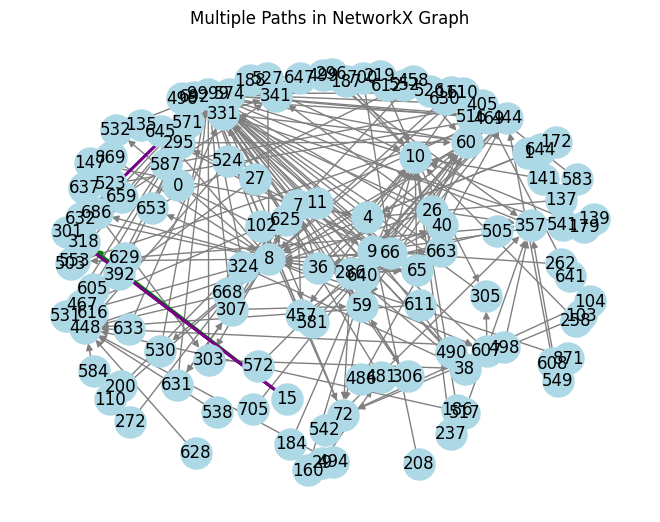

In [298]:
import networkx as nx
import matplotlib.pyplot as plt


# Example: multiple paths as lists of nodes
#paths = df_min_weight_paths['path']
paths = df_shortest_paths_with_weight['path']
# Create an empty graph
G = nx.DiGraph()

# Add edges from all paths
for path in paths:
# Add edges for consecutive pairs of nodes in the path
    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)

# Draw the graph
pos = nx.spring_layout(G, scale=2,k=0.85, iterations=50) # Layout algorithm for positions
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

# Optionally highlight each path in a different colour
colors = ['red', 'green', 'blue', 'purple']
for path, color in zip(paths, colors):
    edges_zip = list(zip(path[:-1], path[1:]))
    nx.draw_networkx_edges(G, pos, edgelist=edges_zip, edge_color=color, width=2)
#plt.figure(figsize=(12, 8))
plt.title("Multiple Paths in NetworkX Graph")
plt.show()

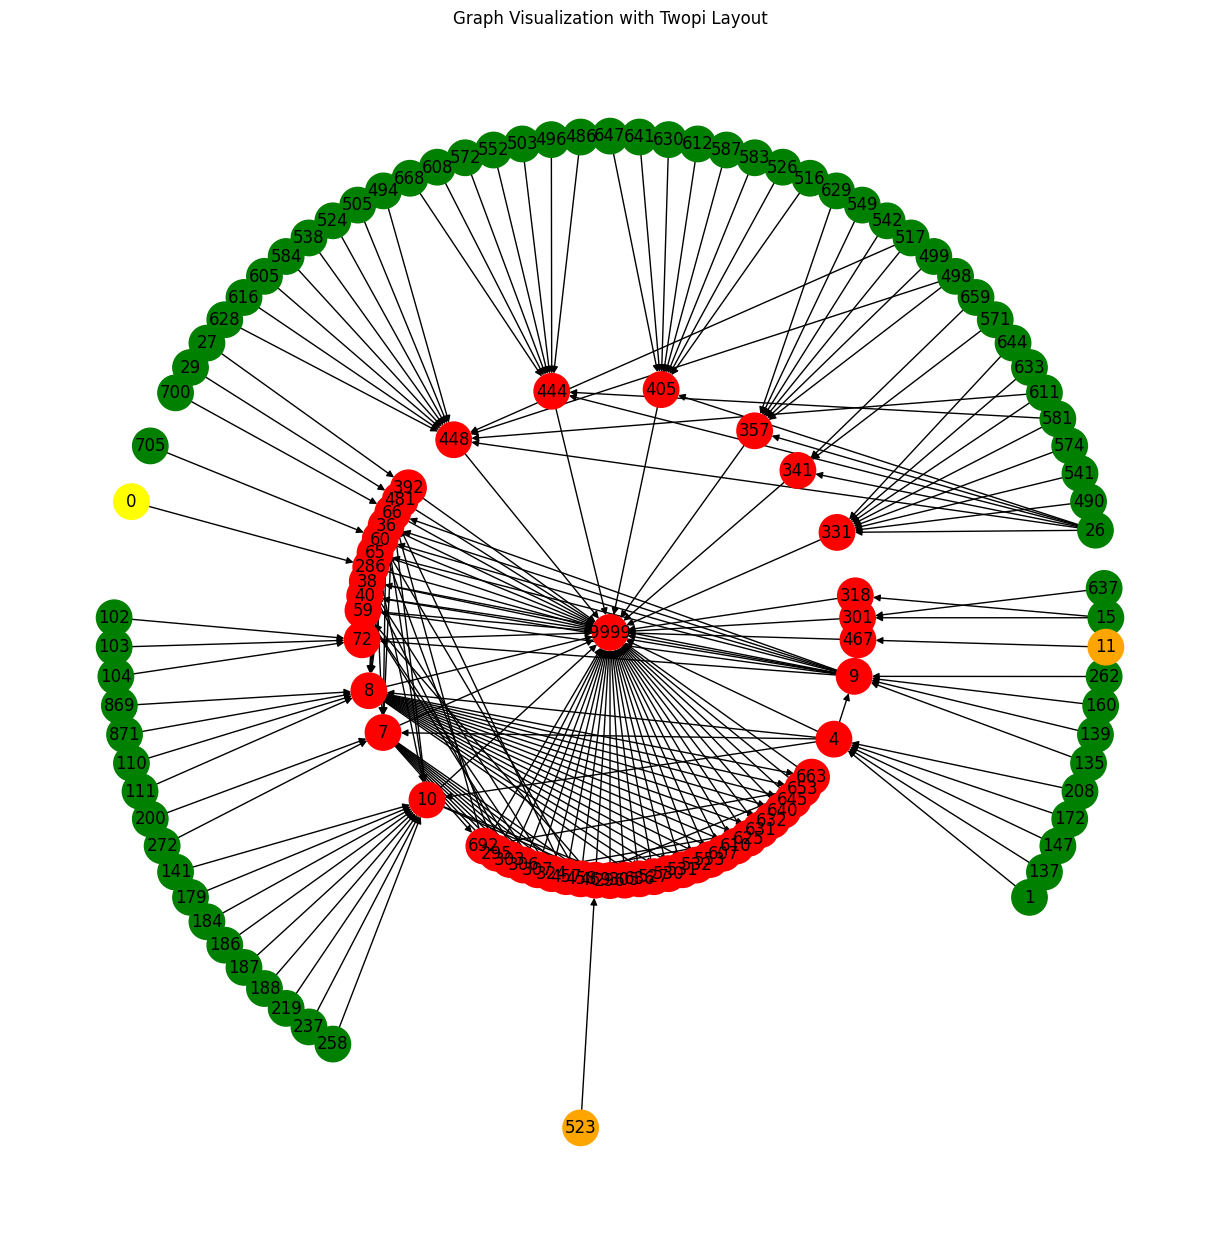

In [299]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight
df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]

G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if int(node) in tier0_node_ids:
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif int(node) in tier1_node_ids:
        colors.append('orange')
        height=4
    elif int(node) in tier2_node_ids:
        colors.append('yellow')
        height=2
    else:
        colors.append('green')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '2.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name_max = suf + '_max_twopi_graph.pdf'
plt.savefig(graph_name_max, format="pdf")
plt.show()

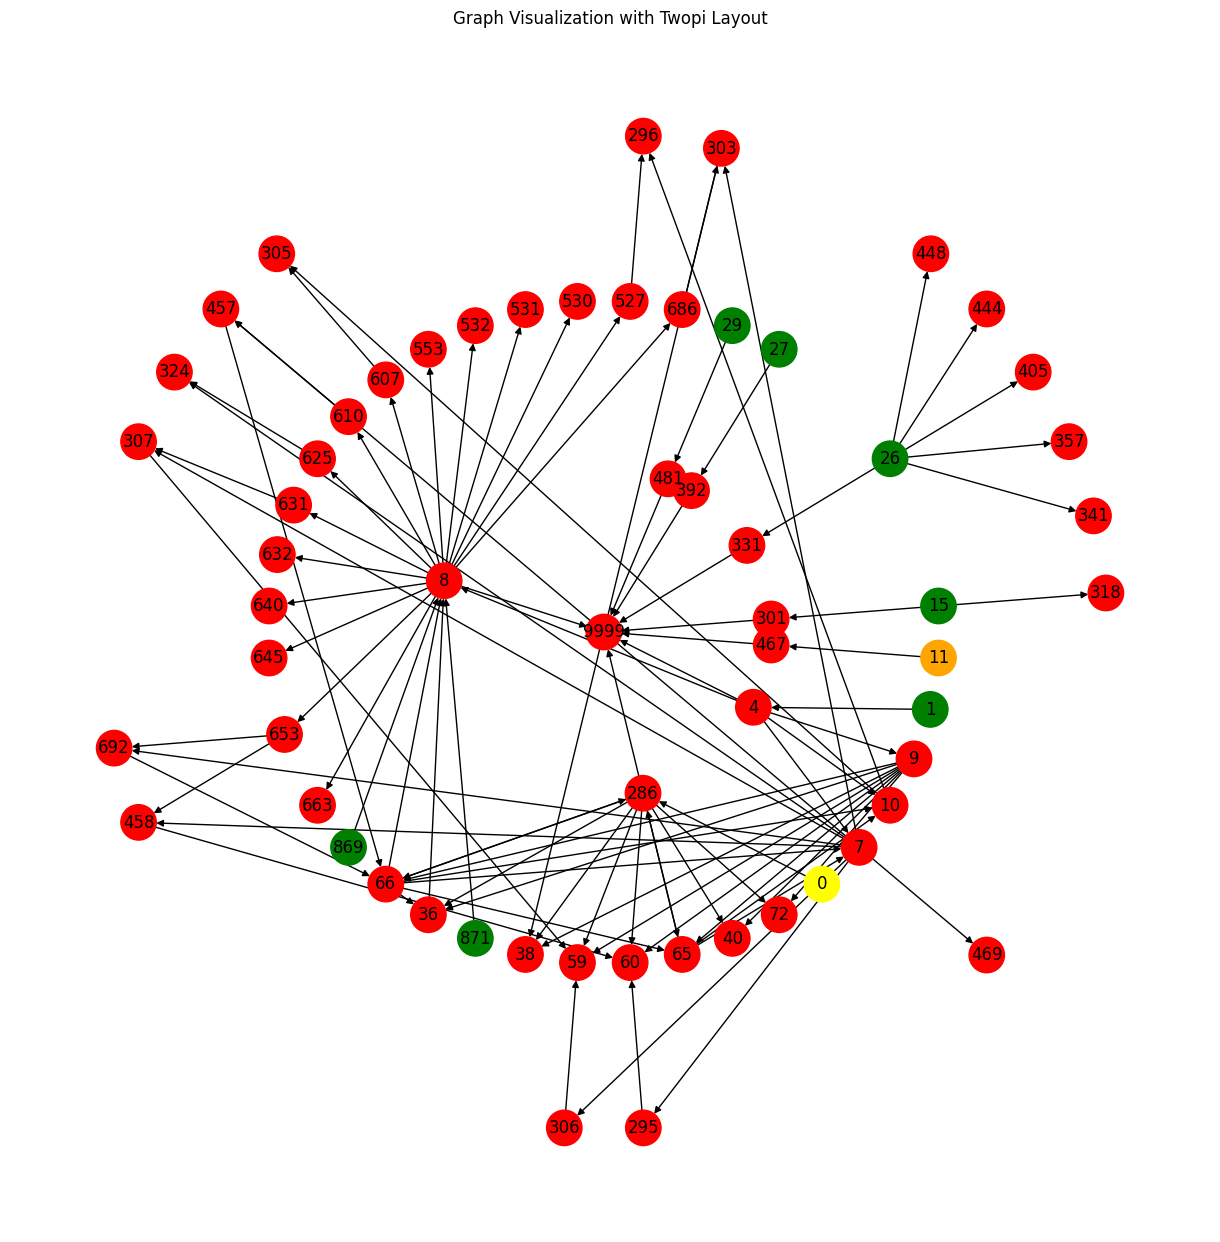

In [300]:
import networkx as nx
import pydot
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import *
# graphviz is installed already, but need lib too
#!apt install libgraphviz-dev
#!pip install pygraphviz
# import pygraphviz as G_pgv

df=df_shortest_paths_with_weight

df_min_weight =2
#df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['target'].isin(tier0_node_ids))]



G = nx.DiGraph()
#graph [root=new_node_id label=twopi]

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []
#Assuming node 4 is the one to highlight
for node in G.nodes():
    if int(node) in tier0_node_ids:
    #== new_node_id : # Ensure comparison is with string if nodes are strings
        colors.append('red')
        height=6
    elif int(node) in tier1_node_ids:
        colors.append('orange')
        height=4
    elif int(node) in tier2_node_ids:
        colors.append('yellow')
        height=2
    else:
        colors.append('green')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0' # Increase separation between ranks
G.graph['nodesep'] = '2.0' # Increase separation between nodes

#G_pgv.graph_attr.update(root=new_node_id,ranksep='3.0',nodesep='2.0')
#G_pgv.draw('pytry.jpg',prog='twopi') # This line caused the error
plt.figure(figsize=(12, 12))
# Use pydot_layout with 'twopi' program
pos = pydot_layout(G, prog="twopi", root=str(new_node_id)) # Removed root as it might not exist in the graph
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
plt.savefig("graph_visualization.pdf", format="pdf")
plt.show()


In [ ]:
# admin_nodes = nodes[
#     nodes['properties'].apply(
#         lambda x: isinstance(x, dict) and 'name' in x and 'administrator' in x['name'].lower()
#     )
# ]
# display(admin_nodes)

In [ ]:

edges.head()

In [ ]:
df_shortest_paths_with_weight.info()


tier2_node_ids = [int(node_id) for node_id in tier2_node_ids]
print(f"Type of elements in tier2_node_ids after conversion: {type(tier2_node_ids[0]) if tier2_node_ids else 'List is empty'}")

In [301]:
import pandas as pd
from pyvis.network import Network
#pyvis.__version__

#Loading the data
#data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
df=df_shortest_paths_with_weight


df_min_weight =2
#df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['target'].isin(tier0_node_ids))]

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
)

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids:
        net.add_node(str(node), label=str(node), color='red') # Added label for better visualization
      else:
        net.add_node(str(node), label=str(node), color='green')

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}") # Added weight and title to edge

graph_name = suf + '_min_graph.html'
net.show(graph_name)

secure_min_graph.html


In [304]:


df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]







#df.columns = ["source", "target", "path", "weight"]
#sample = df.sample(500, random_state = 1)
#sample.head(10)

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
)

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids:
        net.add_node(str(node), label=str(node), color='red') # Added label for better visualization
      elif node in tier1_node_ids:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids:
        net.add_node(str(node), label=str(node), color='yellow')
      else:
        net.add_node(str(node), label=str(node), color='green')

    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight}") # Added weight and title to edge
graph_name = suf + '_max_graph.html'
net.show(graph_name)

secure_max_graph.html


In [305]:
for index, row in df_max.iterrows():
    path = row['path']
    print(f"Path: {path}")
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            # Get the properties and check for 'name' and Tier information
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = node_info.iloc[0]['Tier0'] == 1
            is_tier1 = node_info.iloc[0]['Tier1'] == 1
            is_tier2 = node_info.iloc[0]['Tier2'] == 1
            print(f"  Node ID: {node_id}, Name: {node_name}, Tier0: {is_tier0}, Tier1: {is_tier1}, Tier2: {is_tier2}")
        else:
            print(f"  Node ID: {node_id} not found in nodes DataFrame.")
    print("-" * 20)

Path: [486, 444, 9999]
  Node ID: 486, Name: WS-00000@MARK.LOCAL, Tier0: False, Tier1: False, Tier2: True
  Node ID: 444, Name: ABARUT00159@MARK.LOCAL, Tier0: True, Tier1: False, Tier2: False
  Node ID: 9999, Name: ALL_T0@TESTLAB.LOCALE, Tier0: True, Tier1: False, Tier2: False
--------------------
Path: [490, 331, 9999]
  Node ID: 490, Name: WS-00004@MARK.LOCAL, Tier0: False, Tier1: False, Tier2: True
  Node ID: 331, Name: LROBERT00044@MARK.LOCAL, Tier0: True, Tier1: False, Tier2: False
  Node ID: 9999, Name: ALL_T0@TESTLAB.LOCALE, Tier0: True, Tier1: False, Tier2: False
--------------------
Path: [494, 448, 9999]
  Node ID: 494, Name: WS-00007@MARK.LOCAL, Tier0: False, Tier1: False, Tier2: True
  Node ID: 448, Name: DGOODKNIGHT00163@MARK.LOCAL, Tier0: True, Tier1: False, Tier2: False
  Node ID: 9999, Name: ALL_T0@TESTLAB.LOCALE, Tier0: True, Tier1: False, Tier2: False
--------------------
Path: [496, 444, 9999]
  Node ID: 496, Name: WS-00009@MARK.LOCAL, Tier0: False, Tier1: False, Tie

In [ ]:
filtered_shortest_paths = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == 1]
display(filtered_shortest_paths)

In [307]:
# Create a list to store the data for the table
table_data = []

# Iterate through the paths in df_max
for index, row in df_max.iterrows():
    path = row['path']
    # path_str = " -> ".join(map(str, path)) # Convert the path list to a string

    # Iterate through the nodes in the current path
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = 1 if node_info.iloc[0]['Tier0'] == 1 else 0
            is_tier1 = 1 if node_info.iloc[0]['Tier1'] == 1 else 0
            is_tier2 = 1 if node_info.iloc[0]['Tier2'] == 1 else 0

            # Append the data as a dictionary to the list
            table_data.append({
                'Node Id': node_id, # Changed 'path' to 'Node Id' and stored node_id
                'Name': node_name,
                'Tier 0': is_tier0,
                'Tier 1': is_tier1,
                'Tier 2': is_tier2
            })

# Create a pandas DataFrame from the list of dictionaries
df_path_info = pd.DataFrame(table_data)

# Display the DataFrame
display(df_path_info)

,Node Id,Name,Tier 0,Tier 1,Tier 2
0,486,WS-00000@MARK.LOCAL,0,0,1
1,444,ABARUT00159@MARK.LOCAL,1,0,0
2,9999,ALL_T0@TESTLAB.LOCALE,1,0,0
3,490,WS-00004@MARK.LOCAL,0,0,1
4,331,LROBERT00044@MARK.LOCAL,1,0,0
5,9999,ALL_T0@TESTLAB.LOCALE,1,0,0
6,494,WS-00007@MARK.LOCAL,0,0,1
7,448,DGOODKNIGHT00163@MARK.LOCAL,1,0,0
8,9999,ALL_T0@TESTLAB.LOCALE,1,0,0
9,496,WS-00009@MARK.LOCAL,0,0,1


In [308]:
latex_table = df_path_info.to_latex(index=False)

file_name = suf + "_max_paths_table.tex"

with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"Table exported to {file_name}")

Table exported to secure_max_paths_table.tex
